# DSCI 503 – Project 02
### Ben Miller

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Part A: Stock Simulation Function
Create a function to randomly generate a sequence of daily stock prices

In [2]:
def simulate_stock(start, rate, vol, days):
    
    daily_yields = np.random.normal(loc=(rate/252), scale=(vol/(252**0.5)), size=days)
    cumulative_yields = np.cumsum(daily_yields)
    daily_multipliers = np.exp(cumulative_yields)
    simulated_prices = np.round(daily_multipliers * start, 2)
    # add the starting price to the beginning of the array
    starting_price = np.array([float(start)])
    return np.concatenate((starting_price, simulated_prices))

Test the simulate_stock function and display the results in a line plot

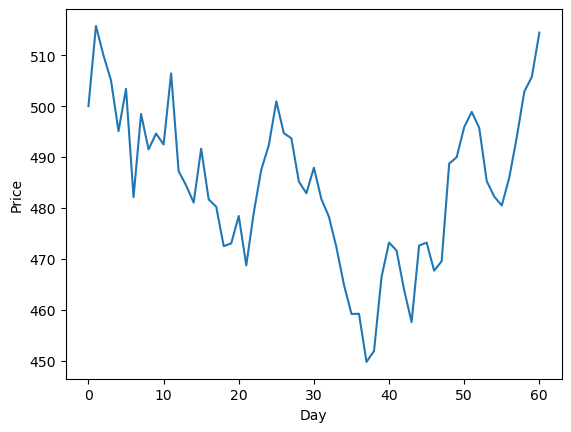

In [3]:
np.random.seed(1)

prices = simulate_stock(500, 0.08, 0.3, 60)

plt.plot(range(0, 61), prices)
plt.xlabel("Day")
plt.ylabel("Price")
plt.show()

# Check if my final result equals the known correct answer (not submitting this output)
# final_price = prices[60]
# print(f"Final Price: {final_price}\nWas the correct answer found: {'Yes' if (final_price == 514.44) else 'No'}")

## Part B: Annual Yield Function
Calculates the annual yield for an array of simulated daily prices

In [4]:
def find_yield(run):
  # annual yield = (ln (final price / initial price)) * 252/days in run
  initial_price = run[0]
  final_price = run[-1]
  days_in_run = (len(run) - 1) # run contains starting price, so subtract 1
  annual_yield = math.log(final_price / initial_price) * 252 / days_in_run

  return round(annual_yield, 4)

Test the find_yield function using the results from simulate_stock

In [5]:
print(find_yield(prices))

0.1196


Explore the potential variability in our simulated runs by creating and plotting 25 simulated runs

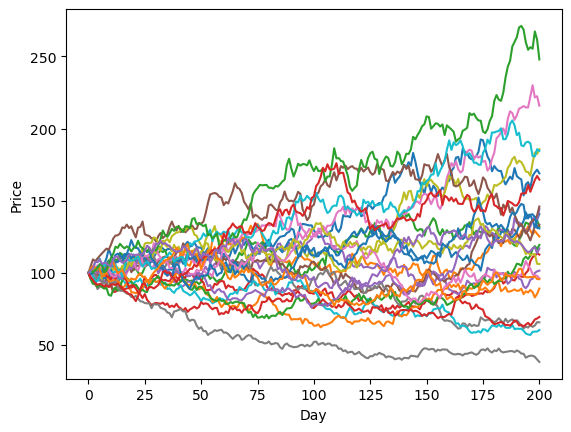

In [6]:
simulated_yields = []
for i in range(25):
   run = simulate_stock(100, 0.06, 0.4, 200)
   plt.plot(range(201), run)

   annual_yield = find_yield(run)
   simulated_yields.append(annual_yield)
      
plt.xlabel("Day")
plt.ylabel("Price")
plt.show()

Print the yields from the 25 test runs

In [7]:
print(simulated_yields)

[0.6611, 0.2836, 0.3501, 0.1506, 0.0198, 0.3635, 0.9697, -0.5283, 0.7798, -0.6351, 0.4319, -0.1446, 0.2234, -0.4586, 0.4608, 0.4768, -0.0479, -1.2092, 0.0748, 0.7724, 0.3386, -0.0558, 1.1441, 0.6283, 0.1978]


## Part C: Finding Seeds that Generate Specific Outcomes
Practice working with seeds and see how they affect the results

In the cell below, Stock A has the highest simulated final price.

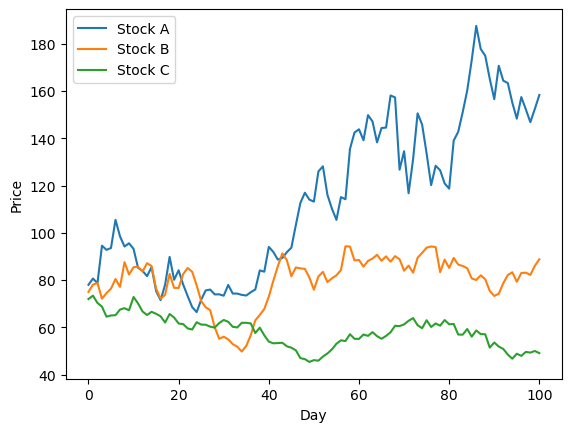

In [8]:
def create_stock_line_plot():
    stock_a = simulate_stock(78, 0.04, 1.2, 100)
    stock_b = simulate_stock(75, 0.08, 0.8, 100)
    stock_c = simulate_stock(72, 0.16, 0.6, 100)

    x_axis = range(101)
    plt.plot(x_axis, stock_a, label="Stock A")
    plt.plot(x_axis, stock_b, label="Stock B")
    plt.plot(x_axis, stock_c, label="Stock C")

    plt.xlabel("Day")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

np.random.seed(5)
create_stock_line_plot()

In the cell below, Stock B has the highest simulated final price.

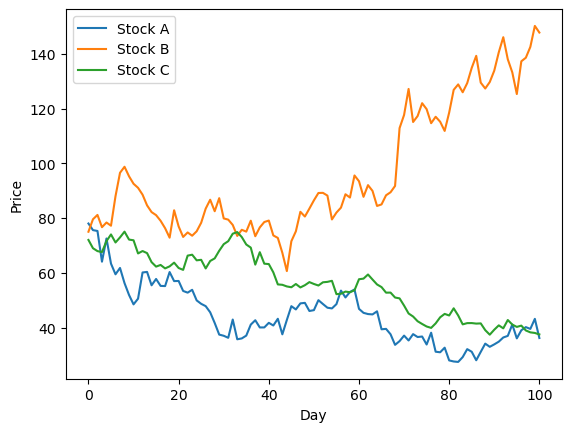

In [9]:
np.random.seed(2)
create_stock_line_plot()

In the cell below, Stock C has the highest simulated final price.

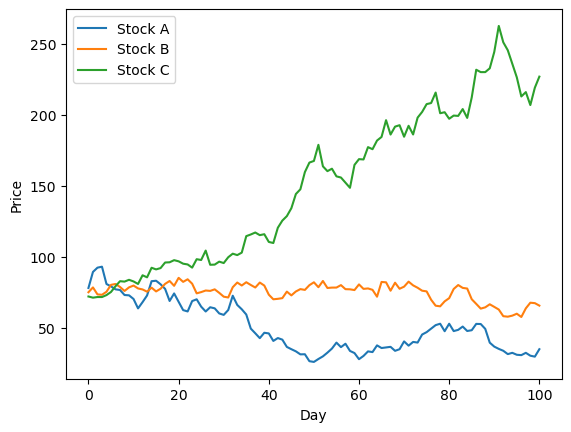

In [10]:
np.random.seed(3)
create_stock_line_plot()

## Part D: Monte Carlo Simulation
perform several monte carlo simulations to estimate probabilities

In [11]:
def monte_carlo(start, rate, vol, days, num_runs):
   
    final_prices = []
    annual_yields = []
    for i in range(num_runs):
        prices = simulate_stock(start, rate, vol, days)
        annual_yield = find_yield(run)

        final_prices.append(prices[-1])
        annual_yields.append(annual_yield)

    return (np.array(final_prices), np.array(annual_yields))

Test the monte_carlo function with a seed of 1 and plot the results

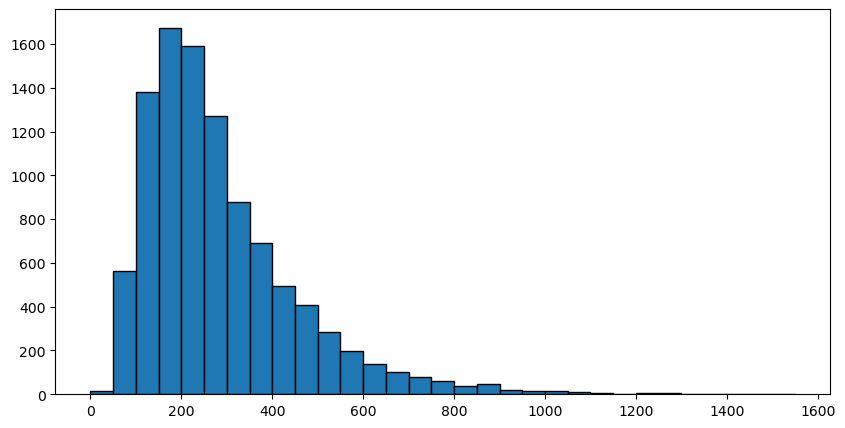

In [12]:
np.random.seed(1)
(final_prices, annual_yields) = monte_carlo(200, 0.1, 0.4, 500, 10000)

plt.figure(figsize=[10,5])
plt.hist(final_prices, edgecolor="black", bins=np.arange(0, 1600, 50))
plt.show()

Display the 10, 20, 50, 75, 90 percentiles of the simulated prices

In [13]:
percentile_10 = np.percentile(final_prices, 10)
percentile_25 = np.percentile(final_prices, 25)
percentile_50 = np.percentile(final_prices, 50)
percentile_75 = np.percentile(final_prices, 75)
percentile_90 = np.percentile(final_prices, 90)

print(f"10th percentile: {percentile_10:.2f}")
print(f"25th percentile: {percentile_25:.2f}")
print(f"50th percentile: {percentile_50:.2f}")
print(f"75th percentile: {percentile_75:.2f}")
print(f"90th percentile: {percentile_90:.2f}")

10th percentile: 118.05
25th percentile: 165.57
50th percentile: 242.95
75th percentile: 357.56
90th percentile: 505.91


## Part E: Effects of Volatility
Test the effect of the volatility parameter by trying different values

In [14]:
np.random.seed(1)

(final_prices_stock_a, annual_yields_stock_a) = monte_carlo(100, .12, 0.3, 150, 10000)
(final_prices_stock_b, annual_yields_stock_b) = monte_carlo(100, .12, 0.7, 150, 10000)

print("Average Annual Yield for A over 10000 runs:", round(np.mean(annual_yields_stock_a),4))
print("Average Annual Yield for B over 10000 runs:", round(np.mean(annual_yields_stock_b),4))

Average Annual Yield for A over 10000 runs: 0.1978
Average Annual Yield for B over 10000 runs: 0.1978


Compare the results by plotting the final prices in a histogram

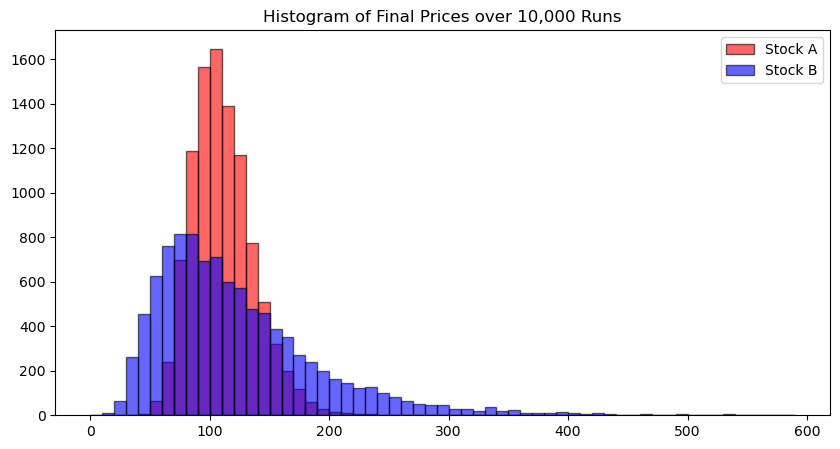

In [15]:
plt.figure(figsize=[10,5])
plt.hist(final_prices_stock_a, color="red", edgecolor="black", label="Stock A", alpha=0.6, bins=np.arange(0, 600, 10))
plt.hist(final_prices_stock_b, color="blue", edgecolor="black", label="Stock B", alpha=0.6, bins=np.arange(0, 600, 10))
plt.legend()
plt.title("Histogram of Final Prices over 10,000 Runs")
plt.show()

## Part F: Comparing Two Stocks
Use the monte_carlo function to estimate probabilities for two stocks

In [16]:
np.random.seed(1)
(final_prices_stock_a, annual_yields_stock_a) = monte_carlo(120, .08, 0.2, 252, 10000)
(final_prices_stock_b, annual_yields_stock_b) = monte_carlo(120, .05, 0.5, 252, 10000)

# find which proportion of results meet different criteria
a_ends_above_b = np.mean(final_prices_stock_a > final_prices_stock_b)
a_ends_above_150 = np.mean(final_prices_stock_a > 150)
b_ends_above_150 = np.mean(final_prices_stock_b > 150)
a_ends_below_100 = np.mean(final_prices_stock_a < 100)
b_ends_below_100 = np.mean(final_prices_stock_b < 100)

print("Proportions of runs in which...")
print("-------------------------------")
print("A ends above B:  ", round(a_ends_above_b, 4), "\n")
print("A ends above 150:", round(a_ends_above_150, 4))
print("B ends above 150:", round(b_ends_above_150, 4), "\n")
print("A ends below 100:", round(a_ends_below_100, 4))
print("B ends below 100:", round(b_ends_below_100, 4))

Proportions of runs in which...
-------------------------------
A ends above B:   0.5206 

A ends above 150: 0.2338
B ends above 150: 0.3619 

A ends below 100: 0.095
B ends below 100: 0.3195


## Part G: Expected Call Payoff
Use the monte_carlo function to estimate expected payoff of a call on a stock

In [17]:
np.random.seed(1)
(prices, yields) = monte_carlo(200, 0.11, 0.4, 150, 10000)

# use a strike price of 225
payoff = prices - 225
# negative values give a return of $0
final_payoff = np.where(payoff > 0, payoff, 0)
print(round(np.mean(final_payoff), 2))

27.1
